In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import xml.etree.ElementTree as ET

# Rutas absolutas — más robusto que relativas
PROJECT_ROOT = Path.home() / "proyectos" / "gasolineras-mty"
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 50)

print(f"DATA_RAW: {DATA_RAW}")
print(f"Archivos disponibles:")
for f in sorted(DATA_RAW.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size / 1024 / 1024:.1f} MB)")

DATA_RAW: /home/osiel/proyectos/gasolineras-mty/data/raw
Archivos disponibles:
  permisos_vigentes.csv  (2.3 MB)
  places.xml  (3.0 MB)
  precios_2025_historico.csv  (150.6 MB)
  precios_2026_01.csv  (47.7 MB)
  precios_2026_02.csv  (42.3 MB)


In [2]:
permisos = pd.read_csv(DATA_RAW / "permisos_vigentes.csv")
print(f"Filas totales en catálogo: {len(permisos):,}")

# Filtros: solo estaciones de servicio vigentes
estaciones = permisos[
    (permisos["tipo_permiso"] == "Expendio en estación de servicio")
    & (permisos["estatus"] == "Vigente")
].copy()

print(f"Estaciones de servicio vigentes (nacional): {len(estaciones):,}")

# Solo Nuevo León
estaciones_nl = estaciones[estaciones["entidad"] == "Nuevo León"].copy()
print(f"Estaciones vigentes en Nuevo León: {len(estaciones_nl):,}")

estaciones_nl.head()

Filas totales en catálogo: 17,840
Estaciones de servicio vigentes (nacional): 13,892
Estaciones vigentes en Nuevo León: 748


,razon_social,num_per,tipo_permiso,fecha_otorgamiento,estatus,entidad,zona_geo
56,"Petromax, S.A. de C.V.",PL/425/EXP/ES/2015,Expendio en estación de servicio,2015-08-13,Vigente,Nuevo León,sin dato
57,"Petromax, S.A. de C.V.",PL/426/EXP/ES/2015,Expendio en estación de servicio,2015-08-13,Vigente,Nuevo León,sin dato
58,"Petromax, S.A. de C.V.",PL/427/EXP/ES/2015,Expendio en estación de servicio,2015-08-13,Vigente,Nuevo León,sin dato
59,"Petromax, S.A. de C.V.",PL/428/EXP/ES/2015,Expendio en estación de servicio,2015-08-13,Vigente,Nuevo León,sin dato
61,"Petromax, S.A. de C.V.",PL/432/EXP/ES/2015,Expendio en estación de servicio,2015-08-13,Vigente,Nuevo León,sin dato


In [3]:
tree = ET.parse(DATA_RAW / "places.xml")
root = tree.getroot()

records = []
for place in root.findall("place"):
    pid = place.get("place_id")
    name = place.findtext("name", "").strip()
    cre_id = place.findtext("cre_id", "").strip()
    loc = place.find("location")
    if loc is not None:
        x_text = loc.findtext("x")
        y_text = loc.findtext("y")
        try:
            x = float(x_text) if x_text else None
            y = float(y_text) if y_text else None
        except ValueError:
            x, y = None, None
    else:
        x, y = None, None
    records.append({"place_id": pid, "name_xml": name, "cre_id": cre_id, "lng": x, "lat": y})

xml_df = pd.DataFrame(records)
print(f"Filas en XML: {len(xml_df):,}")
print(f"Sin coordenadas: {xml_df['lat'].isna().sum()}")
print(f"Lat range: {xml_df['lat'].min():.4f} a {xml_df['lat'].max():.4f}")
print(f"Lng range: {xml_df['lng'].min():.4f} a {xml_df['lng'].max():.4f}")

xml_df.head()

Filas en XML: 14,745
Sin coordenadas: 0
Lat range: 0.0000 a 32.7163
Lng range: -117.1202 a 0.0000


,place_id,name_xml,cre_id,lng,lat
0,2039,ESTACION HIPODROMO SA DE CV,PL/658/EXP/ES/2015,-116.92140,32.47641
1,2040,LAS MEJORES ESTACIONES SA DE CV,PL/902/EXP/ES/2015,-99.74484,20.30370
2,2041,DIAZ GAS SA DE CV,PL/760/EXP/ES/2015,-106.45140,31.71947
3,2042,COMBU-EXPRESS SA DE CV,PL/825/EXP/ES/2015,-103.30420,20.71413
4,2043,PETROMAX SA DE CV,PL/585/EXP/ES/2015,-98.29977,26.03787


In [4]:
# Join por num_per (catálogo) ↔ cre_id (XML)
estaciones_nl_full = estaciones_nl.merge(
    xml_df,
    left_on="num_per",
    right_on="cre_id",
    how="left",
    indicator=True
)

print("Resultado del join:")
print(estaciones_nl_full["_merge"].value_counts())

print(f"\nTotal estaciones NL con coordenadas: {(estaciones_nl_full['_merge'] == 'both').sum()}")
print(f"Estaciones NL sin match en XML: {(estaciones_nl_full['_merge'] == 'left_only').sum()}")

# Coordenadas dentro del rango razonable de NL
# (NL aprox: lat 23.2-27.8, lng -101.2 a -98.7)
fuera_de_nl = estaciones_nl_full[
    (estaciones_nl_full["_merge"] == "both")
    & ~(
        estaciones_nl_full["lat"].between(23.0, 28.0)
        & estaciones_nl_full["lng"].between(-101.5, -98.5)
    )
]
print(f"\nEstaciones marcadas como NL pero con coordenadas FUERA de NL: {len(fuera_de_nl)}")
if len(fuera_de_nl) > 0:
    print(fuera_de_nl[["num_per", "razon_social", "lat", "lng"]].head(10))

Resultado del join:
_merge
both          748
left_only       0
right_only      0
Name: count, dtype: int64

Total estaciones NL con coordenadas: 748
Estaciones NL sin match en XML: 0

Estaciones marcadas como NL pero con coordenadas FUERA de NL: 6
                  num_per                                   razon_social       lat        lng
198   PL/3071/EXP/ES/2015              Servicio Costa Esmeralda Sa de Cv  15.87116  -97.08965
571  PL/10051/EXP/ES/2015                          Servi Benzin Sa de Cv  15.73297  -96.47381
626  PL/13070/EXP/ES/2016                            Celia Bernal Bernal  23.78664 -106.60980
635  PL/18935/EXP/ES/2016  Servicios Gasolineros de Mexico, S.A. de C.V.  20.61954 -101.66800
649  PL/20326/EXP/ES/2017         Hidrocarburos Handall Sa de Cv (10988)  18.54572  -88.29104
717  PL/24950/EXP/ES/2023        Combustibles de Oriente, S. A. de C. V.  19.36290  -99.18980


In [5]:
# Bbox aproximado de la ZM Monterrey
# Cubre: Monterrey, San Pedro, San Nicolás, Guadalupe, Apodaca,
# Escobedo, García, Santa Catarina, Juárez, Cadereyta, Salinas Victoria
ZM_BBOX = {
    "lng_min": -100.65,
    "lng_max": -99.95,
    "lat_min": 25.55,
    "lat_max": 25.95,
}

estaciones_zm = estaciones_nl_full[
    (estaciones_nl_full["_merge"] == "both")
    & (estaciones_nl_full["lng"].between(ZM_BBOX["lng_min"], ZM_BBOX["lng_max"]))
    & (estaciones_nl_full["lat"].between(ZM_BBOX["lat_min"], ZM_BBOX["lat_max"]))
].drop(columns=["_merge", "cre_id"]).reset_index(drop=True)

print(f"Estaciones en bbox ZM Monterrey: {len(estaciones_zm)}")
print(f"\nMuestra:")
estaciones_zm[["num_per", "razon_social", "lat", "lng"]].head(10)

Estaciones en bbox ZM Monterrey: 620

Muestra:


,num_per,razon_social,lat,lng
0,PL/425/EXP/ES/2015,"Petromax, S.A. de C.V.",25.71970,-100.3590
1,PL/426/EXP/ES/2015,"Petromax, S.A. de C.V.",25.60693,-100.2683
2,PL/427/EXP/ES/2015,"Petromax, S.A. de C.V.",25.67366,-100.3682
3,PL/428/EXP/ES/2015,"Petromax, S.A. de C.V.",25.75267,-100.1985
4,PL/432/EXP/ES/2015,"Petromax, S.A. de C.V.",25.68003,-100.2656
5,PL/433/EXP/ES/2015,"Petromax, S.A. de C.V.",25.71057,-100.2634
6,PL/437/EXP/ES/2015,"Petromax, S.A. de C.V.",25.62543,-100.1731
7,PL/439/EXP/ES/2015,"Petromax, S.A. de C.V.",25.77202,-100.2918
8,PL/441/EXP/ES/2015,"Petromax, S.A. de C.V.",25.70874,-100.2766
9,PL/444/EXP/ES/2015,"Petromax, S.A. de C.V.",25.66751,-100.3207


In [6]:
# Mensuales — ya están en formato long (numero_permiso, fecha, subproducto, precio)
precios_ene = pd.read_csv(DATA_RAW / "precios_2026_01.csv")
precios_feb = pd.read_csv(DATA_RAW / "precios_2026_02.csv")

precios_ene["fecha"] = pd.to_datetime(precios_ene["fecha"])
precios_feb["fecha"] = pd.to_datetime(precios_feb["fecha"])

print(f"Enero 2026: {len(precios_ene):,} filas, {precios_ene['fecha'].nunique()} días")
print(f"  Rango: {precios_ene['fecha'].min().date()} a {precios_ene['fecha'].max().date()}")
print(f"  Subproductos: {precios_ene['subproducto'].unique()}")

print(f"\nFebrero 2026: {len(precios_feb):,} filas, {precios_feb['fecha'].nunique()} días")
print(f"  Rango: {precios_feb['fecha'].min().date()} a {precios_feb['fecha'].max().date()}")
print(f"  Subproductos: {precios_feb['subproducto'].unique()}")

Enero 2026: 1,048,575 filas, 31 días
  Rango: 2026-01-01 a 2026-01-31
  Subproductos: <ArrowStringArray>
['regular', 'premium', 'diesel_automotriz', 'duba']
Length: 4, dtype: str

Febrero 2026: 920,989 filas, 27 días
  Rango: 2026-02-02 a 2026-02-28
  Subproductos: <ArrowStringArray>
['regular', 'diésel automotríz', 'premium', 'dUBA']
Length: 4, dtype: str


In [7]:
# Histórico 2025 — formato WIDE, va del 01/01/2025 al 31/08/2025
precios_2025 = pd.read_csv(DATA_RAW / "precios_2025_historico.csv")
print(f"Filas totales 2025 histórico: {len(precios_2025):,}")
print(f"Columnas: {list(precios_2025.columns)}")

# La fecha viene como dd/mm/yyyy — formato distinto a los mensuales
precios_2025["fecha"] = pd.to_datetime(precios_2025["fecha"], format="%d/%m/%Y")

print(f"\nRango: {precios_2025['fecha'].min().date()} a {precios_2025['fecha'].max().date()}")
print(f"Días únicos: {precios_2025['fecha'].nunique()}")

# ¿Hay filas de diciembre 2025?
diciembre = precios_2025[precios_2025["fecha"].dt.month == 12]
print(f"\nFilas de DICIEMBRE 2025: {len(diciembre):,}")

Filas totales 2025 histórico: 2,841,462
Columnas: ['numero_permiso', 'fecha', 'anio', 'regular', 'premium', 'diesel_automotriz', 'diesel_industrial', 'diesel_agricola_marino', 'diesel_ultra_bajo_azufre_DUBA']

Rango: 2025-01-01 a 2025-08-31
Días únicos: 243

Filas de DICIEMBRE 2025: 0


In [8]:
# Decisión: análisis sobre enero + febrero 2026 = 58 días contiguos
# (Diciembre 2025 no está disponible en los archivos públicos al cierre de este análisis)
precios_recientes = pd.concat([precios_ene, precios_feb], ignore_index=True)

print(f"Total filas (ene + feb 2026): {len(precios_recientes):,}")
print(f"Días únicos: {precios_recientes['fecha'].nunique()}")
print(f"Rango: {precios_recientes['fecha'].min().date()} a {precios_recientes['fecha'].max().date()}")
print(f"\nSubproductos:")
print(precios_recientes['subproducto'].value_counts())

Total filas (ene + feb 2026): 1,969,564
Días únicos: 58
Rango: 2026-01-01 a 2026-02-28

Subproductos:
subproducto
regular              733176
premium              673356
diesel_automotriz    274055
diésel automotríz    234616
duba                  28956
dUBA                  25405
Name: count, dtype: int64


In [9]:
# Días esperados vs días reales
fechas_reales = sorted(precios_recientes["fecha"].dt.date.unique())
rango_esperado = pd.date_range(fechas_reales[0], fechas_reales[-1]).date

faltantes = sorted(set(rango_esperado) - set(fechas_reales))
print(f"Días en el rango: {len(rango_esperado)}")
print(f"Días con datos: {len(fechas_reales)}")
print(f"Días faltantes: {len(faltantes)}")
if faltantes:
    print(f"Fechas faltantes: {faltantes}")

Días en el rango: 59
Días con datos: 58
Días faltantes: 1
Fechas faltantes: [datetime.date(2026, 2, 1)]


In [10]:
# Filtrar a solo Magna (regular) — es lo único que vamos a analizar
magna = precios_recientes[precios_recientes["subproducto"] == "regular"].copy()
print(f"Filas de Magna (regular): {len(magna):,}")

# Estadísticos
print(f"\nDistribución de precios:")
print(magna["precio"].describe())

# Precios sospechosos
muy_bajos = magna[magna["precio"] < 15]
muy_altos = magna[magna["precio"] > 35]
print(f"\nPrecios <$15/L (sospechosos por bajos): {len(muy_bajos)}")
print(f"Precios >$35/L (sospechosos por altos): {len(muy_altos)}")

if len(muy_bajos) > 0:
    print(f"\nMuestra de precios bajos:")
    print(muy_bajos.sort_values("precio").head(10))

if len(muy_altos) > 0:
    print(f"\nMuestra de precios altos:")
    print(muy_altos.sort_values("precio", ascending=False).head(10))

Filas de Magna (regular): 733,176

Distribución de precios:
count    733176.000000
mean         23.570466
std           1.017957
min          16.190000
25%          23.490000
50%          23.990000
75%          23.990000
max          29.990000
Name: precio, dtype: float64

Precios <$15/L (sospechosos por bajos): 0
Precios >$35/L (sospechosos por altos): 0


In [11]:
# ¿Hay (numero_permiso, fecha) duplicados en Magna?
dups = magna.duplicated(subset=["numero_permiso", "fecha"], keep=False)
print(f"Filas duplicadas en (permiso, fecha): {dups.sum()}")

if dups.sum() > 0:
    print(f"\nEjemplos de duplicados:")
    print(magna[dups].sort_values(["numero_permiso", "fecha"]).head(20))

Filas duplicadas en (permiso, fecha): 0


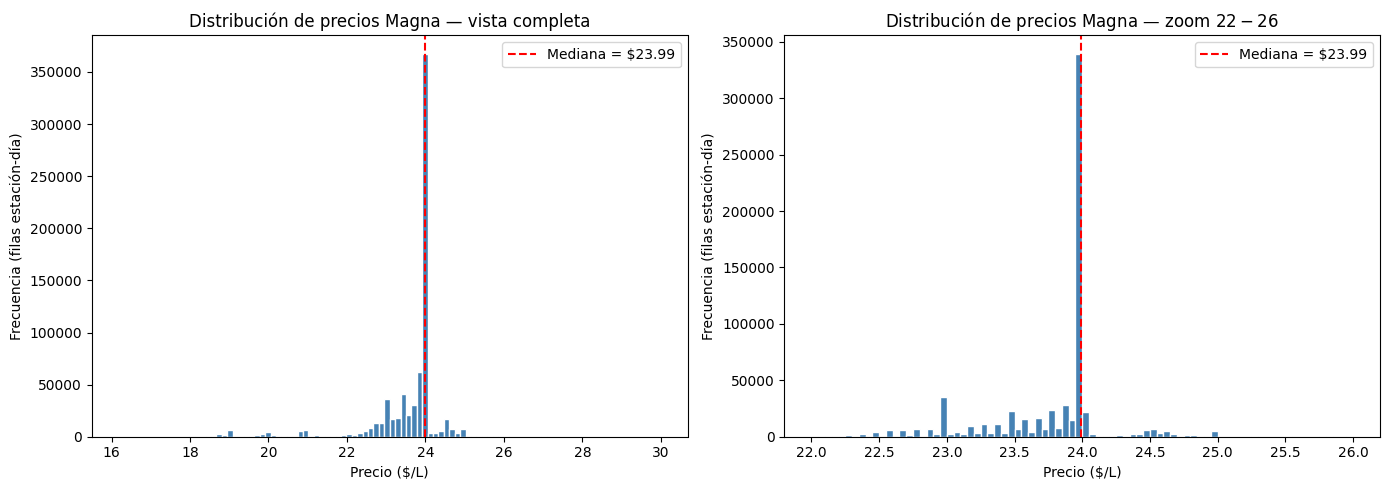


Top 15 precios más comunes:
precio
23.99    300177
22.99     28464
24.00     22141
23.89     18678
23.49     17653
23.98     17377
23.79     15605
23.95     14821
23.69     12737
23.59     11030
23.90      8333
23.39      8207
23.29      7948
23.19      7766
18.99      5787
Name: count, dtype: int64

Total precios distintos: 481


In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma izquierdo: vista completa
axes[0].hist(magna["precio"], bins=100, color="steelblue", edgecolor="white")
axes[0].axvline(magna["precio"].median(), color="red", linestyle="--", 
                label=f"Mediana = ${magna['precio'].median():.2f}")
axes[0].set_title("Distribución de precios Magna — vista completa")
axes[0].set_xlabel("Precio ($/L)")
axes[0].set_ylabel("Frecuencia (filas estación-día)")
axes[0].legend()

# Histograma derecho: zoom al rango central donde está el grueso
zoom = magna[magna["precio"].between(22, 26)]
axes[1].hist(zoom["precio"], bins=80, color="steelblue", edgecolor="white")
axes[1].axvline(magna["precio"].median(), color="red", linestyle="--",
                label=f"Mediana = ${magna['precio'].median():.2f}")
axes[1].set_title("Distribución de precios Magna — zoom $22-$26")
axes[1].set_xlabel("Precio ($/L)")
axes[1].set_ylabel("Frecuencia (filas estación-día)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Top 10 precios más frecuentes
print("\nTop 15 precios más comunes:")
print(magna["precio"].value_counts().head(15))
print(f"\nTotal precios distintos: {magna['precio'].nunique()}")

In [13]:
# Lista de num_per de las 620 estaciones de la ZM Monterrey
permisos_zm = set(estaciones_zm["num_per"])
print(f"Permisos en bbox ZM Monterrey: {len(permisos_zm)}")

# Filtrar la base de Magna a solo esas estaciones
magna_zm = magna[magna["numero_permiso"].isin(permisos_zm)].copy()
print(f"Filas Magna en ZM Monterrey: {len(magna_zm):,}")
print(f"Estaciones únicas reportando Magna en ZM: {magna_zm['numero_permiso'].nunique()}")
print(f"Días únicos: {magna_zm['fecha'].nunique()}")

Permisos en bbox ZM Monterrey: 620
Filas Magna en ZM Monterrey: 33,391
Estaciones únicas reportando Magna en ZM: 588
Días únicos: 58


In [14]:
# ¿Cuántos días reporta cada estación de Magna en los 58 días?
cobertura = (
    magna_zm.groupby("numero_permiso")["fecha"]
    .nunique()
    .reset_index()
    .rename(columns={"fecha": "dias_reportados"})
    .sort_values("dias_reportados")
)

print("Distribución de días reportados por estación:")
print(cobertura["dias_reportados"].describe())

print(f"\n--- Estaciones por nivel de cobertura ---")
print(f"Reportan los 58 días: {(cobertura['dias_reportados'] == 58).sum()}")
print(f"Reportan ≥41 días (≥70% del periodo): {(cobertura['dias_reportados'] >= 41).sum()}")
print(f"Reportan <41 días: {(cobertura['dias_reportados'] < 41).sum()}")
print(f"Reportan <14 días: {(cobertura['dias_reportados'] < 14).sum()}")

# Las que reportan poco no nos sirven para análisis de persistencia
print(f"\nMuestra de estaciones con cobertura baja:")
cobertura.head(15)

Distribución de días reportados por estación:
count    588.000000
mean      56.787415
std        6.509124
min        9.000000
25%       58.000000
50%       58.000000
75%       58.000000
max       58.000000
Name: dias_reportados, dtype: float64

--- Estaciones por nivel de cobertura ---
Reportan los 58 días: 559
Reportan ≥41 días (≥70% del periodo): 572
Reportan <41 días: 16
Reportan <14 días: 4

Muestra de estaciones con cobertura baja:


,numero_permiso,dias_reportados
364,PL/6123/EXP/ES/2015,9
369,PL/6333/EXP/ES/2015,9
333,PL/5709/EXP/ES/2015,9
312,PL/540/EXP/ES/2015,11
22,PL/12030/EXP/ES/2015,17
13,PL/10961/EXP/ES/2015,19
12,PL/10958/EXP/ES/2015,19
14,PL/10963/EXP/ES/2015,19
15,PL/10967/EXP/ES/2015,19
26,PL/12570/EXP/ES/2015,19


In [15]:
print("Distribución de precios Magna en ZM Monterrey:")
print(magna_zm["precio"].describe())

print(f"\nPrecios distintos en ZM: {magna_zm['precio'].nunique()}")

print(f"\nTop 15 precios más comunes en ZM Monterrey:")
print(magna_zm["precio"].value_counts().head(15))

# Comparación: ¿el clustering nacional aplica también localmente?
mediana_zm = magna_zm["precio"].median()
pct_2399_zm = (magna_zm["precio"] == 23.99).sum() / len(magna_zm) * 100
print(f"\nMediana en ZM Monterrey: ${mediana_zm}")
print(f"% de observaciones a $23.99 en ZM Monterrey: {pct_2399_zm:.1f}%")
print(f"(Recordatorio: a nivel nacional fue 41%)")

Distribución de precios Magna en ZM Monterrey:
count    33391.000000
mean        23.883695
std          0.328506
min         22.150000
25%         23.980000
50%         23.990000
75%         23.990000
max         27.490000
Name: precio, dtype: float64

Precios distintos en ZM: 71

Top 15 precios más comunes en ZM Monterrey:
precio
23.99    24266
23.79      932
23.88      712
23.03      680
23.98      665
23.89      643
23.19      606
22.99      604
23.74      454
23.49      422
23.69      360
23.59      288
23.94      224
22.89      174
23.95      174
Name: count, dtype: int64

Mediana en ZM Monterrey: $23.99
% de observaciones a $23.99 en ZM Monterrey: 72.7%
(Recordatorio: a nivel nacional fue 41%)


In [16]:
# Promedio de precio por estación en los 58 días
precio_promedio_estacion = (
    magna_zm.groupby("numero_permiso")["precio"]
    .agg(["mean", "median", "count"])
    .reset_index()
    .rename(columns={"mean": "precio_promedio", "median": "precio_mediano", "count": "dias_reportados"})
)

# Filtrar a las que tienen cobertura suficiente (≥41 días = 70%)
precio_estacion = precio_promedio_estacion[precio_promedio_estacion["dias_reportados"] >= 41].copy()
precio_estacion["sobreprecio_vs_2399"] = precio_estacion["precio_mediano"] - 23.99

print(f"Estaciones con cobertura ≥70%: {len(precio_estacion)}")
print(f"\nDistribución del SOBREPRECIO mediano vs $23.99:")
print(precio_estacion["sobreprecio_vs_2399"].describe())

# Top 10 estaciones más caras en su mediana de los 58 días
print(f"\n--- TOP 10 estaciones con mayor mediana de precio ---")
top_caras = precio_estacion.merge(
    estaciones_zm[["num_per", "razon_social"]],
    left_on="numero_permiso",
    right_on="num_per"
).sort_values("precio_mediano", ascending=False).head(10)

print(top_caras[["numero_permiso", "razon_social", "precio_mediano", "sobreprecio_vs_2399", "dias_reportados"]].to_string(index=False))

# ¿Cuántas estaciones cumplen el umbral preliminar de $0.50/L?
arriba_50_centavos = precio_estacion[precio_estacion["sobreprecio_vs_2399"] >= 0.50]
print(f"\n--- Estaciones con mediana ≥$0.50 sobre $23.99 ---")
print(f"Total: {len(arriba_50_centavos)} estaciones de {len(precio_estacion)} ({len(arriba_50_centavos)/len(precio_estacion)*100:.1f}%)")

Estaciones con cobertura ≥70%: 572

Distribución del SOBREPRECIO mediano vs $23.99:
count    572.000000
mean      -0.113462
std        0.302400
min       -1.790000
25%       -0.010000
50%        0.000000
75%        0.000000
max        1.000000
Name: sobreprecio_vs_2399, dtype: float64

--- TOP 10 estaciones con mayor mediana de precio ---
      numero_permiso                razon_social  precio_mediano  sobreprecio_vs_2399  dias_reportados
 PL/2698/EXP/ES/2015 Segas Combustibles Sa de Cv           24.99                 1.00               58
PL/13580/EXP/ES/2016      Petromax, S.A. de C.V.           24.39                 0.40               58
PL/21791/EXP/ES/2018      Petromax, S.A. de C.V.           24.34                 0.35               58
  PL/486/EXP/ES/2015      Petromax, S.A. de C.V.           24.34                 0.35               58
PL/20776/EXP/ES/2017      Petromax, S.A. de C.V.           24.24                 0.25               58
  PL/458/EXP/ES/2015      Petromax, S.A. 

In [17]:
# Umbral final: $0.20/L sobre el precio de referencia ($23.99)
UMBRAL_SOBREPRECIO = 0.20
PRECIO_REFERENCIA = 23.99

# Aplicar umbral sobre la mediana de cada estación (cobertura ≥70% ya filtrada antes)
caras_por_mediana = precio_estacion[
    precio_estacion["sobreprecio_vs_2399"] >= UMBRAL_SOBREPRECIO
].copy()

caras_por_mediana = caras_por_mediana.merge(
    estaciones_zm[["num_per", "razon_social", "lat", "lng"]],
    left_on="numero_permiso",
    right_on="num_per"
).drop(columns=["num_per"])

print(f"Estaciones con mediana ≥${UMBRAL_SOBREPRECIO}/L sobre ${PRECIO_REFERENCIA}: {len(caras_por_mediana)}")
print(f"De {len(precio_estacion)} con cobertura suficiente ({len(caras_por_mediana)/len(precio_estacion)*100:.1f}%)")

print(f"\n--- Distribución por marca (heurística rápida sobre razón social) ---")
def detectar_marca(nombre):
    nombre_upper = nombre.upper()
    marcas = ["PETROMAX", "PEMEX", "SHELL", "BP", "MOBIL", "OXXO", "HIDROSINA",
              "G500", "ARCO", "CHEVRON", "TOTAL", "REPSOL", "GULF", "ORSAN",
              "LA GAS", "WAYPOINT", "REDCO", "FULLGAS"]
    for marca in marcas:
        if marca in nombre_upper:
            return marca
    return "OTRA / NO IDENTIFICADA"

caras_por_mediana["marca_inferida"] = caras_por_mediana["razon_social"].apply(detectar_marca)
print(caras_por_mediana["marca_inferida"].value_counts())

print(f"\n--- Top 20 estaciones más caras (por mediana) ---")
print(
    caras_por_mediana
    .sort_values("precio_mediano", ascending=False)
    .head(20)
    [["numero_permiso", "razon_social", "marca_inferida", "precio_mediano", "sobreprecio_vs_2399", "dias_reportados"]]
    .to_string(index=False)
)

Estaciones con mediana ≥$0.2/L sobre $23.99: 6
De 572 con cobertura suficiente (1.0%)

--- Distribución por marca (heurística rápida sobre razón social) ---
marca_inferida
PETROMAX                  5
OTRA / NO IDENTIFICADA    1
Name: count, dtype: int64

--- Top 20 estaciones más caras (por mediana) ---
      numero_permiso                razon_social         marca_inferida  precio_mediano  sobreprecio_vs_2399  dias_reportados
 PL/2698/EXP/ES/2015 Segas Combustibles Sa de Cv OTRA / NO IDENTIFICADA           24.99                 1.00               58
PL/13580/EXP/ES/2016      Petromax, S.A. de C.V.               PETROMAX           24.39                 0.40               58
  PL/486/EXP/ES/2015      Petromax, S.A. de C.V.               PETROMAX           24.34                 0.35               58
PL/21791/EXP/ES/2018      Petromax, S.A. de C.V.               PETROMAX           24.34                 0.35               58
PL/20776/EXP/ES/2017      Petromax, S.A. de C.V.               PE

In [18]:
# ¿Cuántas estaciones cobraron alguna vez ≥$24.19 (= $23.99 + $0.20)?
UMBRAL_PRECIO = 23.99 + 0.20  # = 24.19

# Filtrar las observaciones donde el precio supera el umbral
obs_caras = magna_zm[magna_zm["precio"] >= UMBRAL_PRECIO]

# Por estación: cuántos días cobró arriba del umbral
dias_caros_por_estacion = (
    obs_caras.groupby("numero_permiso")
    .agg(
        dias_arriba_umbral=("fecha", "nunique"),
        precio_promedio_dias_caros=("precio", "mean"),
        precio_max=("precio", "max"),
    )
    .reset_index()
)

# Cruzar con cobertura total para calcular % persistencia
dias_caros_por_estacion = dias_caros_por_estacion.merge(
    cobertura, on="numero_permiso"
)
dias_caros_por_estacion["pct_dias_caros"] = (
    dias_caros_por_estacion["dias_arriba_umbral"] / dias_caros_por_estacion["dias_reportados"] * 100
)

# Solo estaciones con cobertura ≥70%
dias_caros_filtradas = dias_caros_por_estacion[
    dias_caros_por_estacion["dias_reportados"] >= 41
].copy()

print(f"Estaciones que cobraron ≥${UMBRAL_PRECIO} al menos UN día: {len(dias_caros_filtradas)}")
print(f"\nDistribución del % de días caros (entre estaciones que tienen al menos 1):")
print(dias_caros_filtradas["pct_dias_caros"].describe())

# Niveles de persistencia
print(f"\n--- Estaciones por nivel de persistencia del sobreprecio ---")
print(f"≥1 día caro:    {(dias_caros_filtradas['pct_dias_caros'] >= 0).sum()} estaciones")
print(f"≥30% de días:   {(dias_caros_filtradas['pct_dias_caros'] >= 30).sum()} estaciones")
print(f"≥50% de días:   {(dias_caros_filtradas['pct_dias_caros'] >= 50).sum()} estaciones")
print(f"≥70% de días:   {(dias_caros_filtradas['pct_dias_caros'] >= 70).sum()} estaciones")
print(f"≥90% de días:   {(dias_caros_filtradas['pct_dias_caros'] >= 90).sum()} estaciones")
print(f"100% de días:   {(dias_caros_filtradas['pct_dias_caros'] == 100).sum()} estaciones")

Estaciones que cobraron ≥$24.189999999999998 al menos UN día: 31

Distribución del % de días caros (entre estaciones que tienen al menos 1):
count     31.000000
mean      28.197998
std       24.049709
min        3.448276
25%        8.620690
50%       12.068966
75%       50.000000
max      100.000000
Name: pct_dias_caros, dtype: float64

--- Estaciones por nivel de persistencia del sobreprecio ---
≥1 día caro:    31 estaciones
≥30% de días:   12 estaciones
≥50% de días:   12 estaciones
≥70% de días:   1 estaciones
≥90% de días:   1 estaciones
100% de días:   1 estaciones


In [19]:
# Las 12 estaciones con ≥30% de días caros
candidatas = dias_caros_filtradas[
    dias_caros_filtradas["pct_dias_caros"] >= 30
].copy()

# Enriquecer con datos del catálogo y coordenadas
candidatas = candidatas.merge(
    estaciones_zm[["num_per", "razon_social", "lat", "lng"]],
    left_on="numero_permiso",
    right_on="num_per"
).drop(columns=["num_per"])

# Mediana general de cada estación (no solo días caros)
medianas = (
    magna_zm.groupby("numero_permiso")["precio"]
    .median()
    .reset_index()
    .rename(columns={"precio": "precio_mediano_total"})
)
candidatas = candidatas.merge(medianas, on="numero_permiso")

# Heurística rápida de marca
candidatas["marca_inferida"] = candidatas["razon_social"].apply(detectar_marca)

# Ordenar por % de días caros descendente
candidatas = candidatas.sort_values("pct_dias_caros", ascending=False).reset_index(drop=True)

print(f"Las {len(candidatas)} estaciones con sobreprecio en ≥30% de días observados:\n")
print(
    candidatas[[
        "numero_permiso", "razon_social", "marca_inferida",
        "precio_mediano_total", "precio_promedio_dias_caros", "precio_max",
        "dias_arriba_umbral", "dias_reportados", "pct_dias_caros"
    ]].to_string(index=False)
)

print(f"\n--- Distribución por marca inferida ---")
print(candidatas["marca_inferida"].value_counts())

print(f"\n--- Razones sociales 'OTRA / NO IDENTIFICADA' (necesitan investigación manual) ---")
otras = candidatas[candidatas["marca_inferida"] == "OTRA / NO IDENTIFICADA"]
if len(otras) > 0:
    print(otras[["numero_permiso", "razon_social"]].to_string(index=False))

Las 12 estaciones con sobreprecio en ≥30% de días observados:

      numero_permiso                razon_social         marca_inferida  precio_mediano_total  precio_promedio_dias_caros  precio_max  dias_arriba_umbral  dias_reportados  pct_dias_caros
 PL/2698/EXP/ES/2015 Segas Combustibles Sa de Cv OTRA / NO IDENTIFICADA                 24.99                   24.990000       24.99                  58               58      100.000000
PL/13580/EXP/ES/2016      Petromax, S.A. de C.V.               PETROMAX                 24.39                   24.471250       24.49                  32               58       55.172414
  PL/486/EXP/ES/2015      Petromax, S.A. de C.V.               PETROMAX                 24.34                   24.380625       24.39                  32               58       55.172414
PL/21791/EXP/ES/2018      Petromax, S.A. de C.V.               PETROMAX                 24.34                   24.380625       24.39                  32               58       55.172414
PL

In [20]:
# ¿Cuántas estaciones Petromax hay en la ZM Monterrey en total?
estaciones_zm["es_petromax"] = (
    estaciones_zm["razon_social"].str.upper().str.contains("PETROMAX", na=False)
)

petromax_zm = estaciones_zm[estaciones_zm["es_petromax"]]
print(f"Total estaciones Petromax en ZM Monterrey: {len(petromax_zm)}")
print(f"Total estaciones (todas las marcas) en ZM Monterrey: {len(estaciones_zm)}")
print(f"Petromax como % del total: {len(petromax_zm) / len(estaciones_zm) * 100:.1f}%")

# Cobertura: ¿cuántas Petromax tienen ≥41 días reportados de Magna?
petromax_permisos = set(petromax_zm["num_per"])
petromax_cobertura = cobertura[cobertura["numero_permiso"].isin(petromax_permisos)]
petromax_con_cobertura = petromax_cobertura[petromax_cobertura["dias_reportados"] >= 41]
print(f"\nPetromax con cobertura ≥41 días: {len(petromax_con_cobertura)} de {len(petromax_zm)}")

# ¿Cuántas de las Petromax con cobertura suficiente cobran caro en algún día?
petromax_caras_alguna_vez = dias_caros_filtradas[
    dias_caros_filtradas["numero_permiso"].isin(petromax_permisos)
]
print(f"\nPetromax que cobraron ≥$24.19 al menos un día: {len(petromax_caras_alguna_vez)}")

# Distribución de % de días caros para TODAS las Petromax
print(f"\n--- Distribución de % de días caros entre Petromax (cobertura ≥41 días) ---")
# Tomar todas las Petromax con cobertura suficiente, no solo las que aparecen en dias_caros_filtradas
todas_petromax_analisis = petromax_con_cobertura.merge(
    dias_caros_filtradas[["numero_permiso", "pct_dias_caros", "dias_arriba_umbral"]],
    on="numero_permiso",
    how="left"
)
# Las que no aparecen en dias_caros_filtradas significa que NUNCA cobraron caro
todas_petromax_analisis["pct_dias_caros"] = todas_petromax_analisis["pct_dias_caros"].fillna(0)
todas_petromax_analisis["dias_arriba_umbral"] = todas_petromax_analisis["dias_arriba_umbral"].fillna(0)

print(f"Total Petromax analizadas: {len(todas_petromax_analisis)}")
print(f"\nDistribución del % de días caros:")
print(todas_petromax_analisis["pct_dias_caros"].describe())

print(f"\n--- Categorías de comportamiento Petromax ---")
print(f"NUNCA cobraron caro:                {(todas_petromax_analisis['pct_dias_caros'] == 0).sum()}")
print(f"Cobraron caro 1-29% de días:        {((todas_petromax_analisis['pct_dias_caros'] > 0) & (todas_petromax_analisis['pct_dias_caros'] < 30)).sum()}")
print(f"Cobraron caro 30-49% de días:       {((todas_petromax_analisis['pct_dias_caros'] >= 30) & (todas_petromax_analisis['pct_dias_caros'] < 50)).sum()}")
print(f"Cobraron caro ≥50% de días:         {(todas_petromax_analisis['pct_dias_caros'] >= 50).sum()}")

# Comparación contra el resto del mercado
no_petromax_permisos = permisos_zm - petromax_permisos
no_petromax_cobertura = cobertura[cobertura["numero_permiso"].isin(no_petromax_permisos)]
no_petromax_con_cobertura = no_petromax_cobertura[no_petromax_cobertura["dias_reportados"] >= 41]
no_petromax_caras = dias_caros_filtradas[
    dias_caros_filtradas["numero_permiso"].isin(no_petromax_permisos)
]
print(f"\n--- Comparación: el resto del mercado ZM (no Petromax) ---")
print(f"Estaciones no-Petromax con cobertura ≥41 días: {len(no_petromax_con_cobertura)}")
print(f"De esas, cuántas cobraron ≥$24.19 alguna vez: {len(no_petromax_caras)}")
print(f"% de no-Petromax que rompió el precio: {len(no_petromax_caras) / len(no_petromax_con_cobertura) * 100:.2f}%")

print(f"\n% de Petromax que rompió el precio: {(todas_petromax_analisis['pct_dias_caros'] > 0).sum() / len(todas_petromax_analisis) * 100:.2f}%")

Total estaciones Petromax en ZM Monterrey: 120
Total estaciones (todas las marcas) en ZM Monterrey: 620
Petromax como % del total: 19.4%

Petromax con cobertura ≥41 días: 113 de 120

Petromax que cobraron ≥$24.19 al menos un día: 11

--- Distribución de % de días caros entre Petromax (cobertura ≥41 días) ---
Total Petromax analizadas: 113

Distribución del % de días caros:
count    113.000000
mean       5.004577
std       15.324412
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       55.172414
Name: pct_dias_caros, dtype: float64

--- Categorías de comportamiento Petromax ---
NUNCA cobraron caro:                102
Cobraron caro 1-29% de días:        0
Cobraron caro 30-49% de días:       0
Cobraron caro ≥50% de días:         11

--- Comparación: el resto del mercado ZM (no Petromax) ---
Estaciones no-Petromax con cobertura ≥41 días: 459
De esas, cuántas cobraron ≥$24.19 alguna vez: 20
% de no-Petromax que rompió el precio: 4.36%

% de Petromax que r

Conteo por categoría:
categoria
Resto mercado coordinado         499
Petromax precio mercado (109)    109
Petromax cara (11)                11
Otras caras (1)                    1
Name: count, dtype: int64



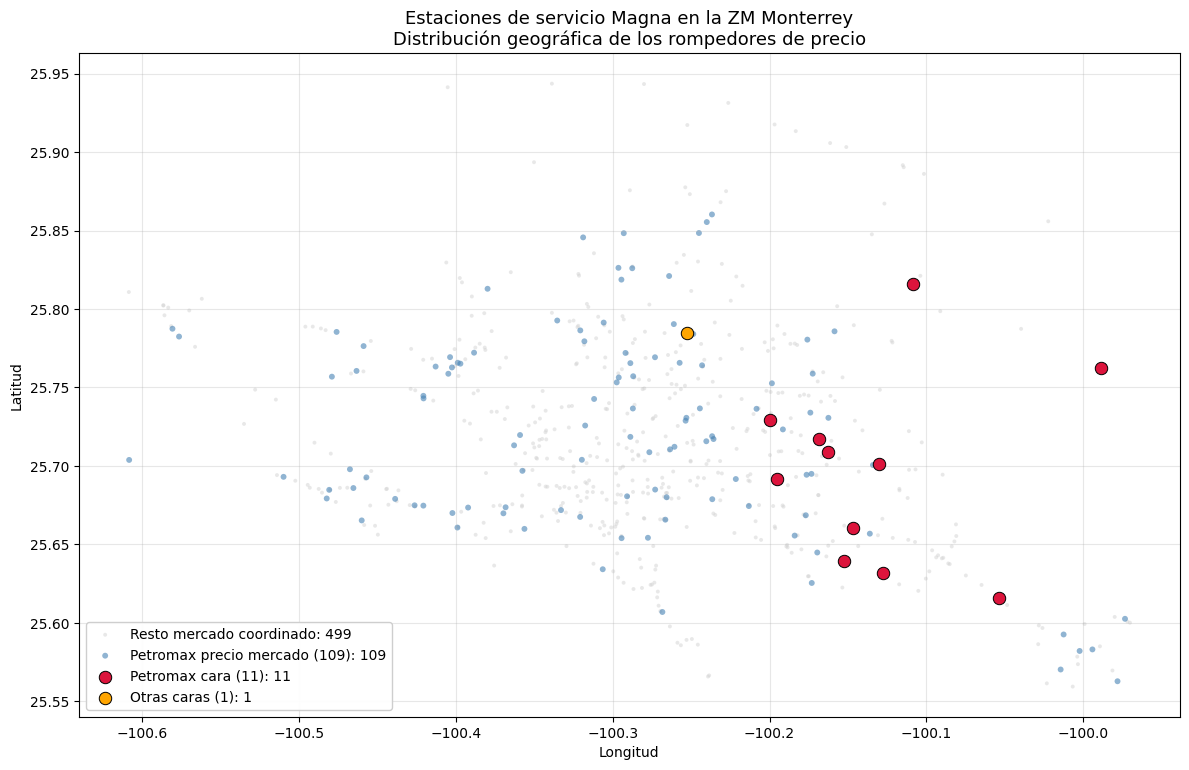


--- Coordenadas medias por grupo ---
Petromax caras (11):    lat=25.6976, lng=-100.1304
Petromax normales (109): lat=25.7209, lng=-100.2972

--- Rango geográfico de las 11 Petromax caras ---
Lat: 25.6159 a 25.8158
Lng: -100.1994 a -99.9890

--- Las 11 Petromax caras, coordenadas exactas ---
             num_per           razon_social      lat        lng
  PL/458/EXP/ES/2015 Petromax, S.A. de C.V. 25.70878 -100.16290
  PL/486/EXP/ES/2015 Petromax, S.A. de C.V. 25.69145 -100.19520
  PL/492/EXP/ES/2015 Petromax, S.A. de C.V. 25.71746 -100.16850
  PL/538/EXP/ES/2015 Petromax, S.A. de C.V. 25.66026 -100.14660
  PL/594/EXP/ES/2015 Petromax, S.A. de C.V. 25.70155 -100.13020
 PL/3811/EXP/ES/2015 Petromax, S.A. de C.V. 25.63936 -100.15240
PL/13580/EXP/ES/2016 Petromax, S.A. de C.V. 25.81581 -100.10860
PL/19022/EXP/ES/2016 Petromax, S.A. de C.V. 25.63159 -100.12800
PL/20776/EXP/ES/2017 Petromax, S.A. de C.V. 25.72923 -100.19940
PL/21791/EXP/ES/2018 Petromax, S.A. de C.V. 25.76265  -99.98902
PL/

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Construir las tres categorías de estaciones para visualizar
estaciones_zm_viz = estaciones_zm.copy()
estaciones_zm_viz["es_petromax"] = (
    estaciones_zm_viz["razon_social"].str.upper().str.contains("PETROMAX", na=False)
)

# Las 11 Petromax caras
permisos_caras_petromax = set(
    candidatas[candidatas["marca_inferida"] == "PETROMAX"]["numero_permiso"]
)
# Las "otras caras" (no Petromax que rompen el precio en ≥30% de días)
permisos_caras_otras = set(
    candidatas[candidatas["marca_inferida"] != "PETROMAX"]["numero_permiso"]
)

def categorizar(row):
    if row["num_per"] in permisos_caras_petromax:
        return "Petromax cara (11)"
    if row["num_per"] in permisos_caras_otras:
        return "Otras caras (1)"
    if row["es_petromax"]:
        return "Petromax precio mercado (109)"
    return "Resto mercado coordinado"

estaciones_zm_viz["categoria"] = estaciones_zm_viz.apply(categorizar, axis=1)

print("Conteo por categoría:")
print(estaciones_zm_viz["categoria"].value_counts())
print()

# Mapa
fig, ax = plt.subplots(figsize=(12, 10))

colores = {
    "Resto mercado coordinado": ("lightgray", 0.5, 8),
    "Petromax precio mercado (109)": ("steelblue", 0.6, 18),
    "Petromax cara (11)": ("crimson", 1.0, 80),
    "Otras caras (1)": ("orange", 1.0, 80),
}

for cat, (color, alpha, size) in colores.items():
    subset = estaciones_zm_viz[estaciones_zm_viz["categoria"] == cat]
    if len(subset) > 0:
        ax.scatter(
            subset["lng"], subset["lat"],
            c=color, alpha=alpha, s=size,
            edgecolors="black" if "cara" in cat else "none",
            linewidths=0.7,
            label=f"{cat}: {len(subset)}",
            zorder=3 if "cara" in cat else 1,
        )

ax.set_title("Estaciones de servicio Magna en la ZM Monterrey\nDistribución geográfica de los rompedores de precio", fontsize=13)
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.legend(loc="lower left", fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

# Estadísticos espaciales: ¿las 11 Petromax caras están más al sur (San Pedro/Valle) que las 109?
petromax_caras_coords = estaciones_zm_viz[estaciones_zm_viz["categoria"] == "Petromax cara (11)"]
petromax_normales_coords = estaciones_zm_viz[estaciones_zm_viz["categoria"] == "Petromax precio mercado (109)"]

print(f"\n--- Coordenadas medias por grupo ---")
print(f"Petromax caras (11):    lat={petromax_caras_coords['lat'].mean():.4f}, lng={petromax_caras_coords['lng'].mean():.4f}")
print(f"Petromax normales (109): lat={petromax_normales_coords['lat'].mean():.4f}, lng={petromax_normales_coords['lng'].mean():.4f}")

print(f"\n--- Rango geográfico de las 11 Petromax caras ---")
print(f"Lat: {petromax_caras_coords['lat'].min():.4f} a {petromax_caras_coords['lat'].max():.4f}")
print(f"Lng: {petromax_caras_coords['lng'].min():.4f} a {petromax_caras_coords['lng'].max():.4f}")

print(f"\n--- Las 11 Petromax caras, coordenadas exactas ---")
print(petromax_caras_coords[["num_per", "razon_social", "lat", "lng"]].to_string(index=False))

In [22]:
# Guardar datasets procesados para 02_analisis.ipynb
PROCESSED = PROJECT_ROOT / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

# 1. Las 620 estaciones de la ZM con coordenadas y razón social
estaciones_zm[["num_per", "razon_social", "lat", "lng"]].to_parquet(
    PROCESSED / "estaciones_zm_monterrey.parquet", index=False
)

# 2. Precios de Magna en ZM Monterrey (33,391 filas)
magna_zm.to_parquet(PROCESSED / "magna_zm_diario.parquet", index=False)

# 3. Las 12 candidatas (11 Petromax + Segas) — para que 02 las re-derive y valide
candidatas[[
    "numero_permiso", "razon_social", "marca_inferida",
    "precio_mediano_total", "precio_promedio_dias_caros", "precio_max",
    "dias_arriba_umbral", "dias_reportados", "pct_dias_caros",
    "lat", "lng"
]].to_parquet(PROCESSED / "estaciones_caras_candidatas.parquet", index=False)

# Verificación
print("Archivos guardados:")
for f in sorted(PROCESSED.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} KB)")

Archivos guardados:
  estaciones_caras_candidatas.parquet  (7.7 KB)
  estaciones_zm_monterrey.parquet  (22.2 KB)
  magna_zm_diario.parquet  (25.1 KB)


# Resumen del EDA — Hallazgos clave

## Pregunta de negocio
¿Qué gasolineras de la Zona Metropolitana de Monterrey cobran Magna sobre el precio coordinado del mercado, con qué persistencia, y cuánto le cuesta al consumidor desinformado al año?

## Datasets utilizados
- **Catálogo de permisos vigentes (CNE)**: 17,840 permisos nacionales, 14,300 de "Expendio en estación de servicio". 748 estaciones vigentes en Nuevo León.
- **XML de places (CRE/CNE)**: 14,745 estaciones nacionales con coordenadas. Join 100% con catálogo NL.
- **Precios diarios mensuales (CNE)**: enero + febrero 2026 = 58 días observados. ~1.97M filas combinadas.
- **Diciembre 2025 no disponible** en archivos públicos al cierre del análisis (rezago documental de la CNE).

## Limitaciones detectadas y reportadas
1. Campo `zona_geo` del catálogo: 97% de los registros con valor "sin dato". No usable.
2. Inconsistencia de nomenclatura de subproductos entre archivos (`diesel_automotriz` en enero vs `diésel automotríz` en febrero). No afecta el análisis (usamos solo `regular`/Magna).
3. 6 estaciones registradas como NL en el catálogo tienen coordenadas fuera del estado. Excluidas por filtro de bounding box.
4. 1 día faltante en febrero (2026-02-01).
5. Ventana de análisis: 58 días contiguos. Decisión metodológica documentada.

## Población de análisis
- 620 estaciones en bounding box de la ZM Monterrey.
- 588 reportan Magna al menos un día.
- **572 con cobertura ≥70% del periodo** (≥41 días). Esta es la base sobre la que se aplican criterios de persistencia.

## Hallazgos principales

### 1. El mercado mexicano de Magna está fuertemente clusterizado
- A nivel nacional, **41% de las observaciones** se reportan a exactamente $23.99/L.
- En la ZM Monterrey, este porcentaje sube a **72.7%** — el mercado local es aún más coordinado que el promedio nacional.
- Esto sugiere precios de referencia compartidos entre operadores, no fijación independiente.

### 2. Solo 31 estaciones rompen el precio coordinado
- Sobre 572 estaciones con cobertura suficiente, solo 31 cobraron al menos un día ≥$24.19/L (umbral $0.20/L sobre el precio de referencia).
- De estas, **12 lo hicieron en ≥30% de los días observados**.

### 3. Patrón bimodal de comportamiento Petromax
- Petromax tiene 120 estaciones en la ZM Monterrey (19.4% del mercado).
- 102 nunca rompen el precio. 11 lo rompen sistemáticamente en ~50-55% de los días. Cero estaciones en zonas intermedias.
- Distribución bimodal perfecta: o cobran al precio coordinado, o cobran $0.15-$0.40 arriba consistentemente.
- **El comportamiento NO es de marca completa, es de subgrupo específico.**

### 4. Concentración geográfica del subgrupo: corredor oriente
- Las 11 Petromax que rompen el precio están concentradas en el corredor Apodaca-Guadalupe-Juárez-Cadereyta.
- Diferencia de longitud media vs Petromax normales: 0.17 grados ≈ 17 km hacia el oriente.
- No hay Petromax caras en San Pedro Garza García (zona tradicionalmente premium).
- Hipótesis (no validada con este dataset): zona de corredor industrial con clientela menos sensible al precio (transportistas, parques industriales).

### 5. Impacto monetario al consumidor
- Sobreprecio mediano de las 11: $0.20-$0.40/L (≈$390-$1,040 anuales para consumo de 50L semanales si visita siempre).
- Costo esperado real (visitando aleatoriamente, dado que cobran caro ~50% de días): $195-$520 anuales.

## Decisiones metodológicas registradas
- **Precio de referencia**: $23.99/L (modal a nivel nacional y local, no mediana de vecindad de 3 km — el clustering hace ambas equivalentes).
- **Umbral de sobreprecio**: $0.20/L absoluto. Justificación: $0.20 × 50L × 52 semanas = $520/año, monto que un consumidor mexicano percibe.
- **Criterio de persistencia**: ≥30% de días observados. El "codo natural" de la distribución separa estaciones sistemáticas de casos aislados.
- **Análisis de vecindad de 3 km**: descartado como sección separada. El comportamiento bimodal y la concentración geográfica del subgrupo lo vuelven redundante. La dimensión geográfica se preserva en el mapa del dashboard.